#1.Descarga y Exploración

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from collections import Counter
from wordcloud import WordCloud
from gensim.models import Word2Vec


ModuleNotFoundError: No module named 'gensim'

In [ ]:
df_full = pd.read_json(
    'Electronics_5.json.gz',
    lines=True,
    nrows=50000#Cargamos 50000 de las más de 6000000 reviews que tiene.
)

In [ ]:
df_full.head()

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,image
0,5,67,True,"09 18, 1999",AAP7PPBU72QFM,0151004714,{'Format:': ' Hardcover'},D. C. Carrad,This is the best novel I have read in 2 or 3 y...,A star is born,937612800,NaN
1,3,5,True,"10 23, 2013",A2E168DTVGE6SV,0151004714,{'Format:': ' Kindle Edition'},Evy,"Pages and pages of introspection, in the style...",A stream of consciousness novel,1382486400,NaN
2,5,4,False,"09 2, 2008",A1ER5AYS3FQ9O3,0151004714,{'Format:': ' Paperback'},Kcorn,This is the kind of novel to read when you hav...,I'm a huge fan of the author and this one did ...,1220313600,NaN
3,5,13,False,"09 4, 2000",A1T17LMQABMBN5,0151004714,{'Format:': ' Hardcover'},Caf Girl Writes,What gorgeous language! What an incredible wri...,The most beautiful book I have ever read!,968025600,NaN
4,3,8,True,"02 4, 2000",A3QHJ0FXK33OBE,0151004714,{'Format:': ' Hardcover'},W. Shane Schmidt,I was taken in by reviews that compared this b...,A dissenting view--In part.,949622400,NaN


In [ ]:
df = df_full[['overall','reviewText']].copy()
df.isna().sum()
df.dropna(inplace=True)

Text(0, 0.5, 'Reviews')

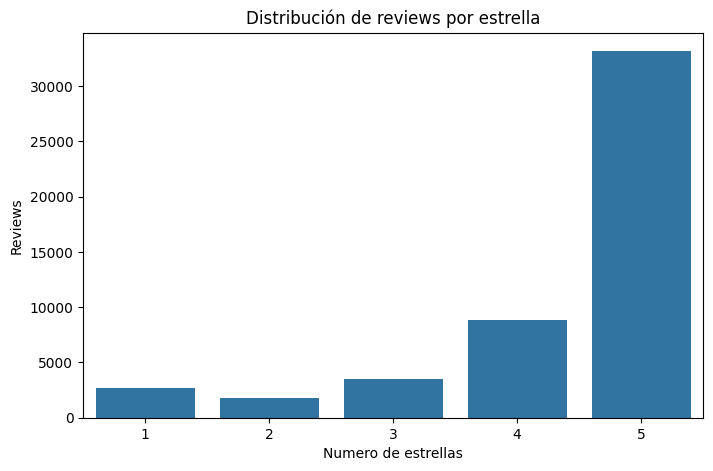

In [ ]:
#Representación grafica de la columna 'overall'
plt.figure(figsize=(8,5))
sns.countplot(
    x='overall',
    data= df
)
plt.title('Distribución de reviews por estrella')
plt.xlabel('Numero de estrellas')
plt.ylabel('Reviews')

In [ ]:
#Eliminamos reviews neutras, ya que no son ni positivas ni negativas.
df = df[df['overall'] !=3]
#Creamos un sistema binario donde, labels positiva = 1 y negativa = 0
df['label'] = df['overall'].apply(lambda x: 1 if x >= 4 else 0)

In [ ]:
#Vemos la cantidad review positivas y negativas,
df['label'].value_counts()

,count
label,
1,42015
0,4460


In [ ]:
total = float(df['label'].count())
n_positivos =  float((df['label'] == 1).sum())
n_negativos =  float((df['label'] == 0).sum())
print(f'El número total de reviews que tenemos es de {total}.')
print(f'El porcentaje total de review positivas es de {(n_positivos/total)*100}.')
print(f'El porcentaje total de review negativas es de {(n_negativos/total)*100}.')

El número total de reviews que tenemos es de 46475.0.
El porcentaje total de review positivas es de 90.40344271113501.
El porcentaje total de review negativas es de 9.59655728886498.


Como se puede ver hay un desbalance entre las dos clases. Cosa que ha futuro nos va a perjudicar en el entrenamiento. Debido ha este gran desajuste es probable que los modelos que realizamos en el Notebook 3 tiendan siempre a tirar a 1 ya que es la clase predominante con un 90%.

En el siguiente notebook trataremos de balancear las clases, ya que se trata de un problema de preprocesamiento. Por ahora continuaremos como está.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pickle
df.to_pickle(
    '/content/drive/MyDrive/NLP_Proyecto_EnriqueToledoPastor/Datasets/df_notebook1.pkl'
)

NameError: name 'df' is not defined

##Cardinalidad

In [ ]:
#Cardinalidad del vocabulario
all_words = ''.join(df['reviewText'].astype(str)).split()
vcocabulary = Counter(all_words)
print(f'Tamaño de vocabulario = {len(vcocabulary)} ')


Tamaño de vocabulario = 127201 


In [ ]:
vcocabulary.most_common(10)
#Todas son stop_words, osea no validos


[('the', 106515),
 ('and', 66774),
 ('to', 64075),
 ('a', 63912),
 ('I', 62053),
 ('is', 36369),
 ('for', 35354),
 ('of', 35058),
 ('it', 34586),
 ('my', 26756)]

##N-grams
---

In [ ]:
#Analisis de ngrams
vectorizer_b = CountVectorizer(
    stop_words= 'english',
    ngram_range= (2,2),#Buscamos bigramas
    max_features=20
)
X = vectorizer_b.fit_transform(df['reviewText'].astype(str))
bigrams = vectorizer_b.get_feature_names_out()
counts_b = X.sum(axis = 0).A1

vectorizer_t = CountVectorizer(
    stop_words= 'english',
    ngram_range= (3,3),#Buscamos trigramas
    max_features=20
)
X = vectorizer_t.fit_transform(df['reviewText'].astype(str))
trigrams = vectorizer_t.get_feature_names_out()
counts_t = X.sum(axis = 0).A1


In [ ]:
#Ordenamos de mayor a menor las listas
sorted_b = counts_b.argsort()[::-1]
sorted_t = counts_t.argsort()[::-1]

top_bigrams = bigrams[sorted_b]
top_counts_b = counts_b[sorted_b]

top_trigrams = trigrams[sorted_t]
top_counts_t = counts_t[sorted_t]

In [ ]:
top_counts_b

array([2237, 1184,  977,  943,  885,  878,  748,  716,  701,  678,  621,
        620,  595,  593,  589,  480,  463,  428,  423,  417])

Text(0, 0.5, 'Frecuencia')

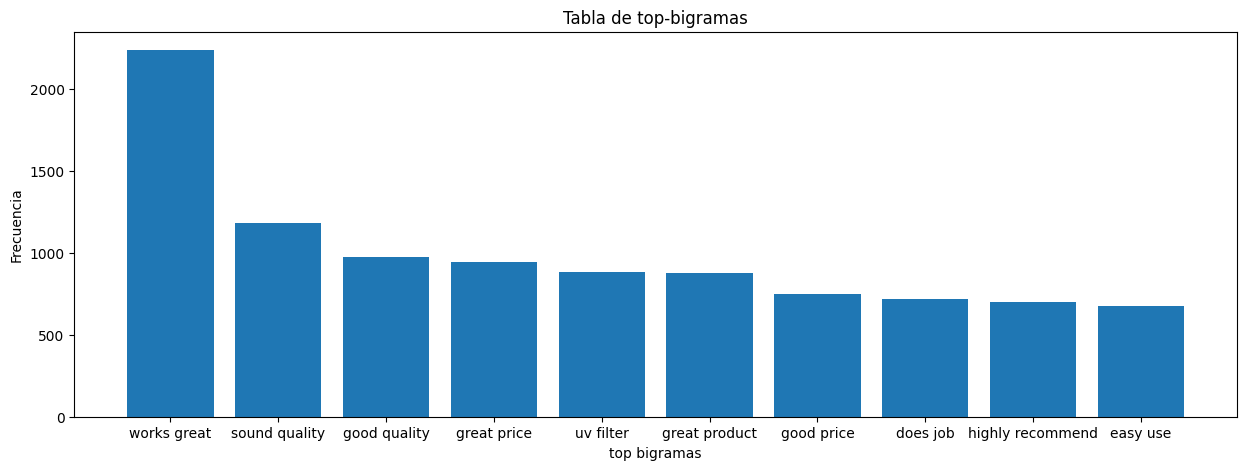

In [ ]:
#Representamos graficamente los bigramas
plt.figure(figsize=(15,5))
plt.bar(
    top_bigrams[:10],
    top_counts_b[:10]
)
plt.title('Tabla de top-bigramas')
plt.xlabel('top bigramas')
plt.ylabel('Frecuencia')

In [ ]:
top_trigrams

array(['link normal href', 'linked class link',
       'ref cm_cr_arp_d_rvw_txt utf8', 'product link linked',
       'data hook product', 'class link normal', 'hook product link',
       'link linked class', 'nbsp data hook', 'uv protection filter',
       'works just fine', 'works like charm', 'buy buy buy',
       'sony mdr v6', 'work just fine', 'sound quality good',
       'good sound quality', 'normal href canon',
       'cm_cr_arp_d_rvw_txt utf8 canon', 'does good job'], dtype=object)

Text(0, 0.5, 'Frecuencia')

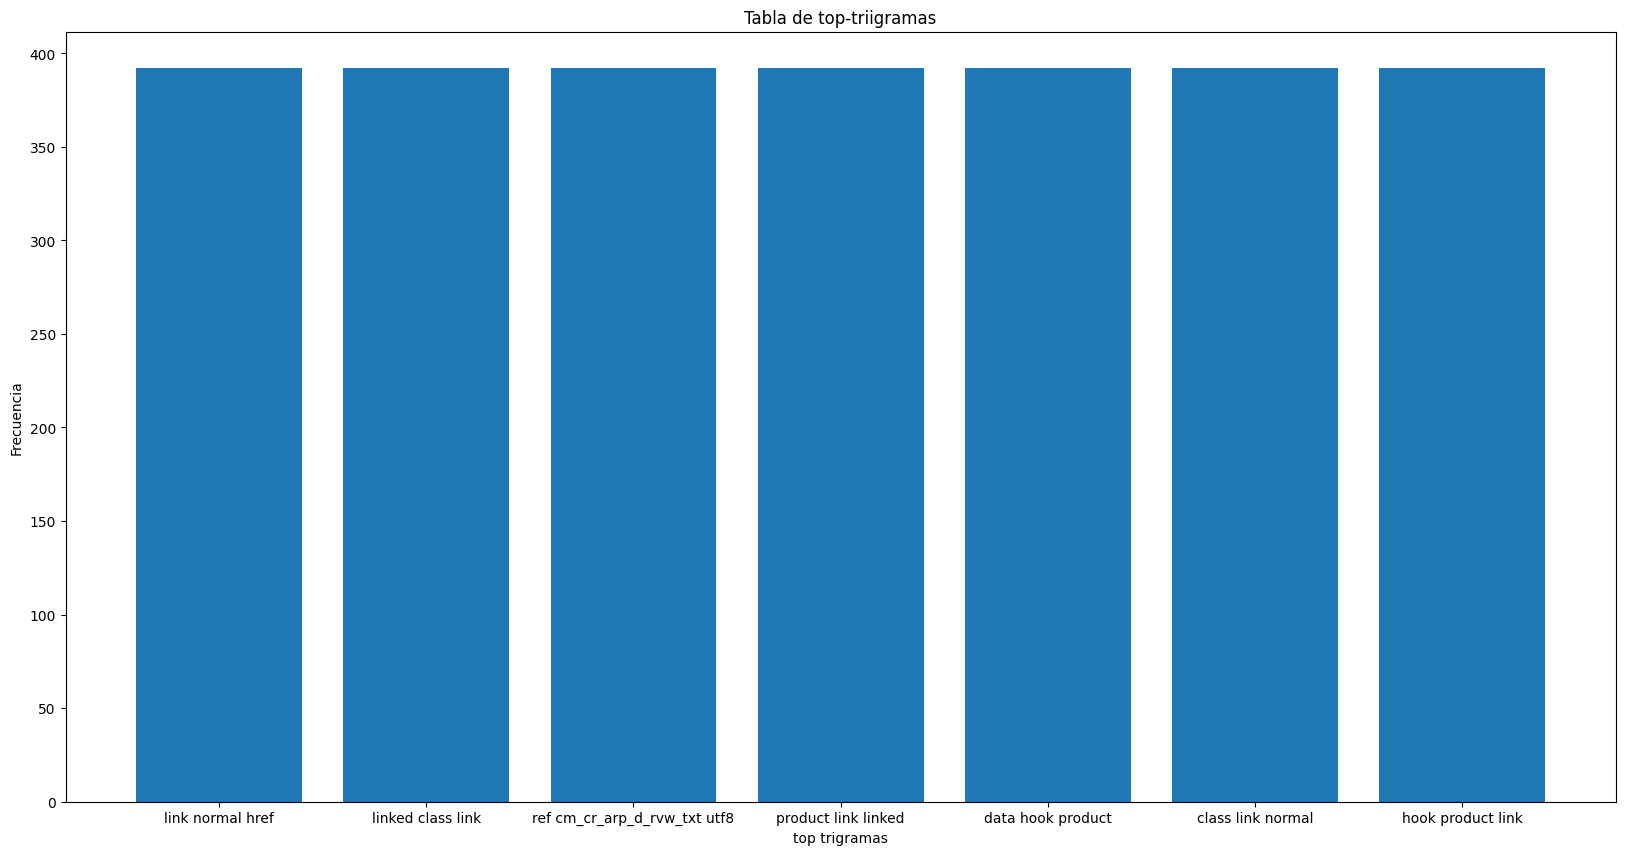

In [ ]:
#Representamos graficamenete los trigramas
plt.figure(figsize=(20,10))
plt.bar(
    top_trigrams[:7],
    top_counts_t[:7]
)
plt.title('Tabla de top-triigramas')
plt.xlabel('top trigramas')
plt.ylabel('Frecuencia')

Aqui podemos ver que casi todos los top no son validos, ya que no son parte de las reviews como tal. Por tanto voy a hacer un apaño, ya que el preprocesamiento es parte del notebook 2. Por tanto lo realizare desde el indice 7 de top_trigrams

Text(0, 0.5, 'Frecuencia')

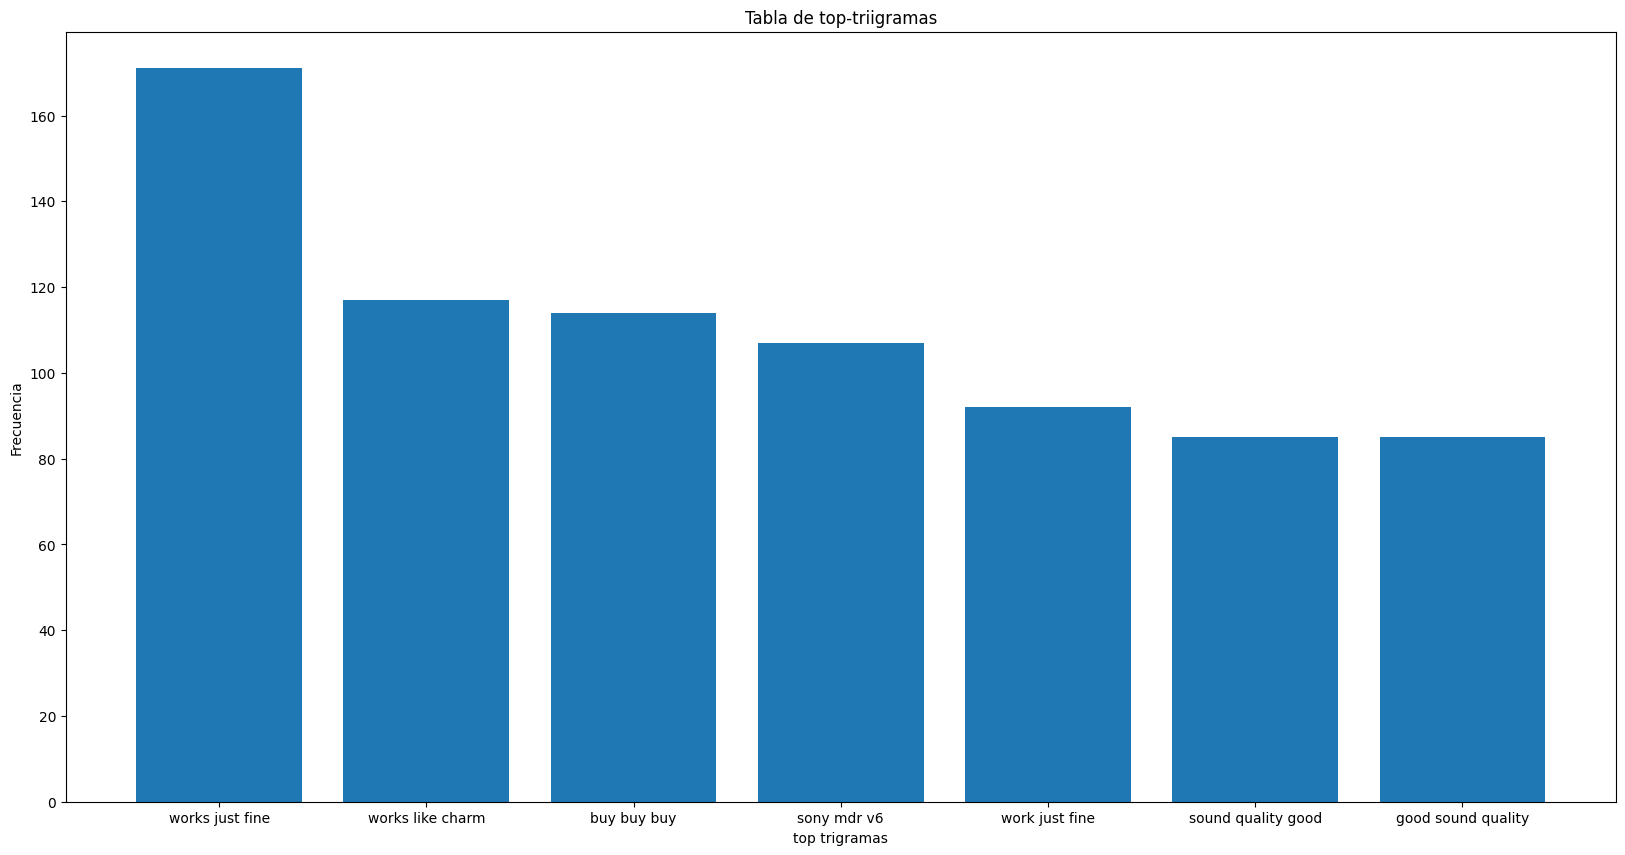

In [ ]:
plt.figure(figsize=(20,10))
plt.bar(
    top_trigrams[10:17],
    top_counts_t[10:17]
)
plt.title('Tabla de top-triigramas')
plt.xlabel('top trigramas')
plt.ylabel('Frecuencia')

## Nube de palabras
---

Text(0.5, 1.0, 'WordCloud Reviews Positivas')

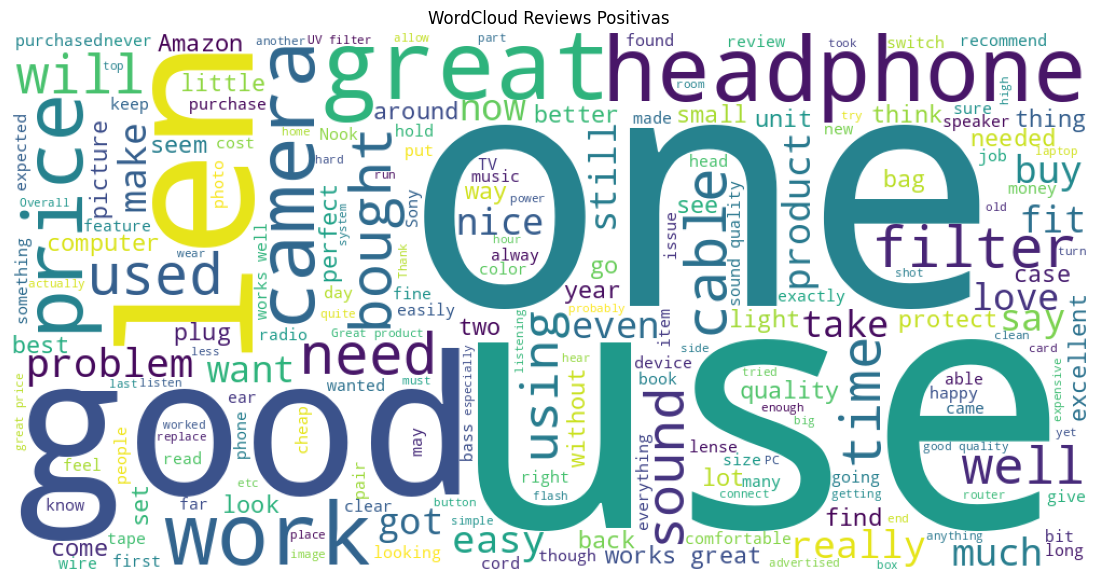

In [ ]:
positive_text = " ".join(
    df[df['label'] == 1]['reviewText'].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud Reviews Positivas")

Text(0.5, 1.0, 'WordCloud Reviews Negativas')

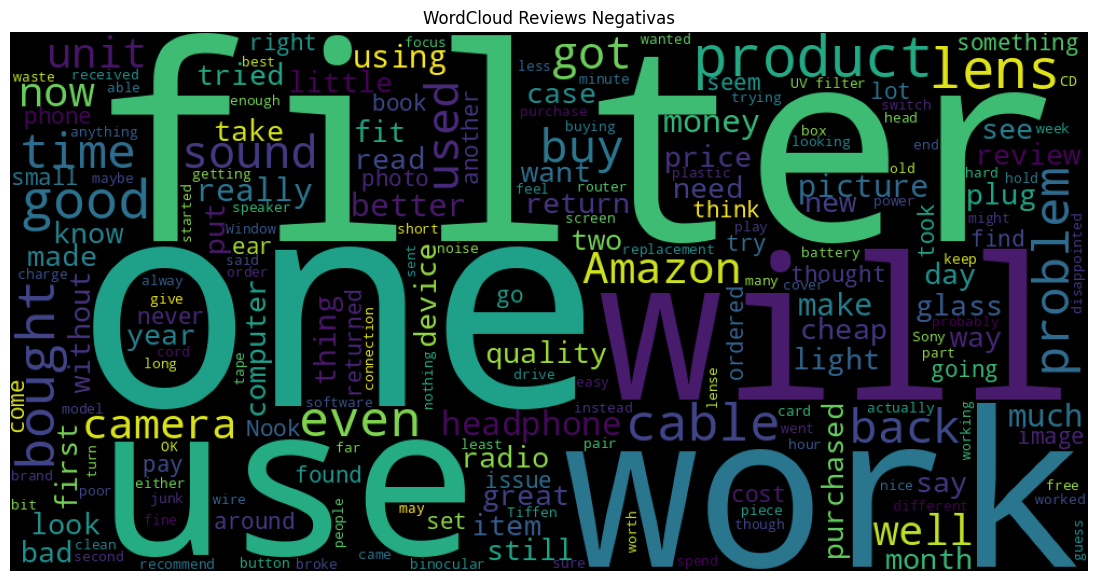

In [ ]:
negative_text = " ".join(
    df[df['label'] == 0]['reviewText'].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(negative_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("WordCloud Reviews Negativas")

## Wor2vec

In [ ]:
import spacy

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=['parser','ner'])#Cargamos modelo de spacy

sentences = []
for text in df['reviewText'].astype(str):
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
      if(not token.is_stop #Eliminamos stop words
         and not token.is_punct#Eliminamos signos de puntuación
         and not token.is_space#Eliminamos espacios
         and token.is_alpha):#Quitamos caracteres especiales
         tokens.append(token.lemma_)
    sentences.append(tokens)

In [ ]:
all_tokens = []#Creamos una lista que contenga todos los tokens procesados
for sentence in sentences:
  for token in sentence:
    all_tokens.append(token)
new_voc = Counter(all_tokens)#Volvemos a contar
new_voc.most_common(10) #Ahora si tenemos una lista fiable de palabras más usadas

[('work', 16504),
 ('good', 15376),
 ('great', 14504),
 ('lens', 11224),
 ('buy', 10561),
 ('use', 10277),
 ('filter', 8679),
 ('price', 8180),
 ('sound', 8115),
 ('like', 7976)]

In [ ]:
w2v_model = Word2Vec(
    sentences,
    vector_size = 100,
    window = 5,
    min_count = 5,
    workers = 4
)

In [ ]:
def plot_similar_words(model, word):
    '''
    Función de representación de palabras más cercanas
    '''
    similar_words = model.wv.most_similar(word, topn=10)#Sacanos las 10 palabras más similares

    words = [word]#Palabra inicial

    words.extend([w[0] for w in similar_words])#Añadimos palabras similares

    vectors = np.array([
        model.wv[w]
        for w in words
    ])

    pca = PCA(n_components=2)#Reducimos las 100 dimensones a 2

    coords = pca.fit_transform(vectors)

    plt.figure(figsize=(10,8))

    for i, w in enumerate(words):

        plt.scatter(
            coords[i,0],
            coords[i,1]
        )

        plt.text(
            coords[i,0],
            coords[i,1],
            w
        )

    plt.title(f"Palabras similares a '{word}'")

    plt.show()

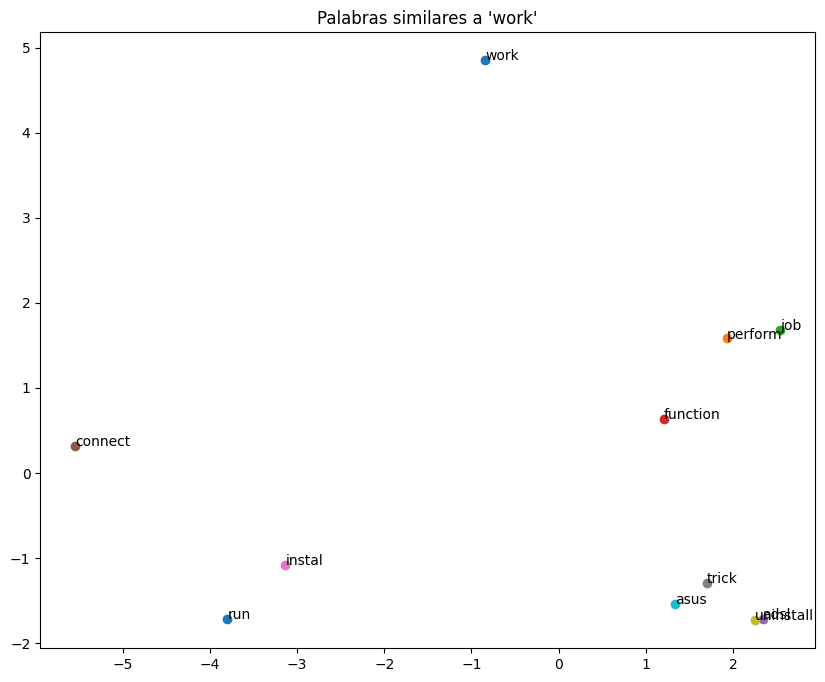

In [ ]:
plot_similar_words(w2v_model,'work' )

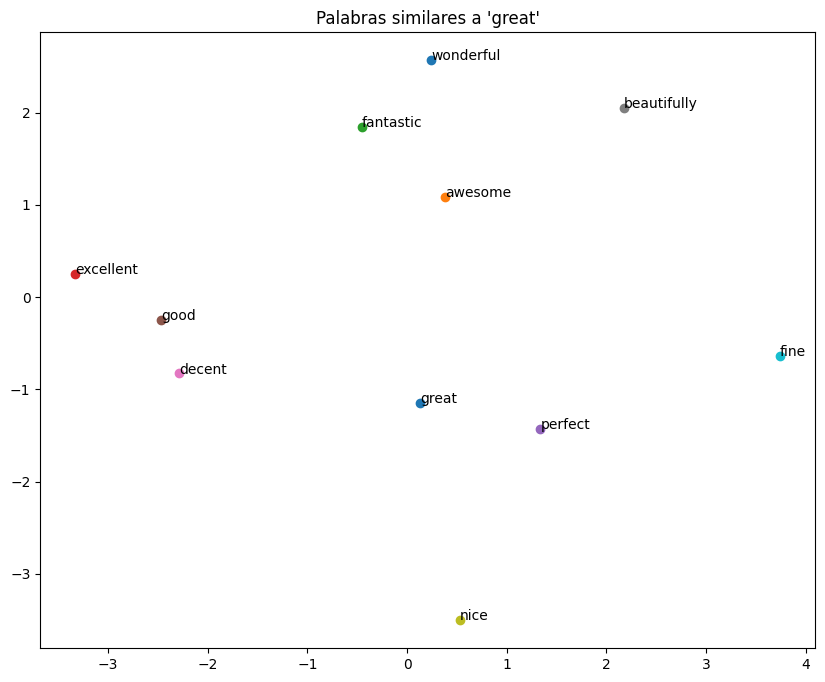

In [ ]:
plot_similar_words(w2v_model,'great' )

##Conclusión
---
Este primer análisis ha servido para conocer mejor el conjunto de datos antes de comenzar con el desarrollo del modelo. Se ha podido comprobar que existe un desbalance importante entre las reviews positivas y negativas, por lo que este aspecto habrá que tenerlo en cuenta en las siguientes etapas del proyecto.

También se ha observado que el texto contiene bastante ruido, como etiquetas HTML o palabras que no aportan información útil para el análisis del sentimiento. Esto justifica la necesidad de realizar un buen preprocesamiento antes de entrenar cualquier modelo.

Por otro lado, el análisis de los n-gramas, las nubes de palabras y Word2Vec ha permitido entender mejor cómo está formado el vocabulario y qué tipo de palabras aparecen con mayor frecuencia.

En general, este análisis exploratorio ha permitido detectar los principales problemas del dataset y conocer mejor la información con la que se va a trabajar. A partir de aquí, el siguiente paso será preparar los datos mediante una etapa de preprocesamiento para reducir el ruido y facilitar el entrenamiento de los modelos de clasificación.
